In [159]:
# Import required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [160]:
# Set plot parameter
plt.rcParams['figure.figsize'] = (10, 7.5)

In [161]:
# Read data file
url = 'https://raw.githubusercontent.com/faadeola/oil_prices_ts_analysis/refs/heads/main/oil_prices_2426.csv'
oil = pd.read_csv(url, parse_dates=['date'], dayfirst=True)

# Save a copy of the data
oil_dup = pd.read_csv(url, parse_dates=['date'], dayfirst=True)

In [162]:
# display sample of data
oil.sample(10)

,date,price (dollars)
109,2025-01-08,22.01
373,2025-09-29,111.58
255,2025-06-03,60.82
192,2025-04-01,50.69
391,2025-10-17,119.31
339,2025-08-26,101.23
462,2025-12-27,154.37
408,2025-11-03,131.50
156,2025-02-24,27.49
100,2024-12-30,25.12


In [163]:
# Display shape of the data
print(f'The oil data consist of {oil.shape[0]} rows and {oil.shape[1]} columns')

The oil data consist of 500 rows and 2 columns


In [164]:
oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             500 non-null    datetime64[ns]
 1   price (dollars)  500 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 7.9 KB


In [165]:
# Display summary statistics of the data
oil.describe().round(2)

,date,price (dollars)
count,500,500.00
mean,2025-05-28 12:00:00,75.87
min,2024-09-21 00:00:00,16.48
25%,2025-01-23 18:00:00,35.37
50%,2025-05-28 12:00:00,64.29
75%,2025-09-30 06:00:00,111.57
max,2026-02-02 00:00:00,158.78
std,NaN,42.91


In [166]:
# set date as the index column
oil = oil.set_index('date')

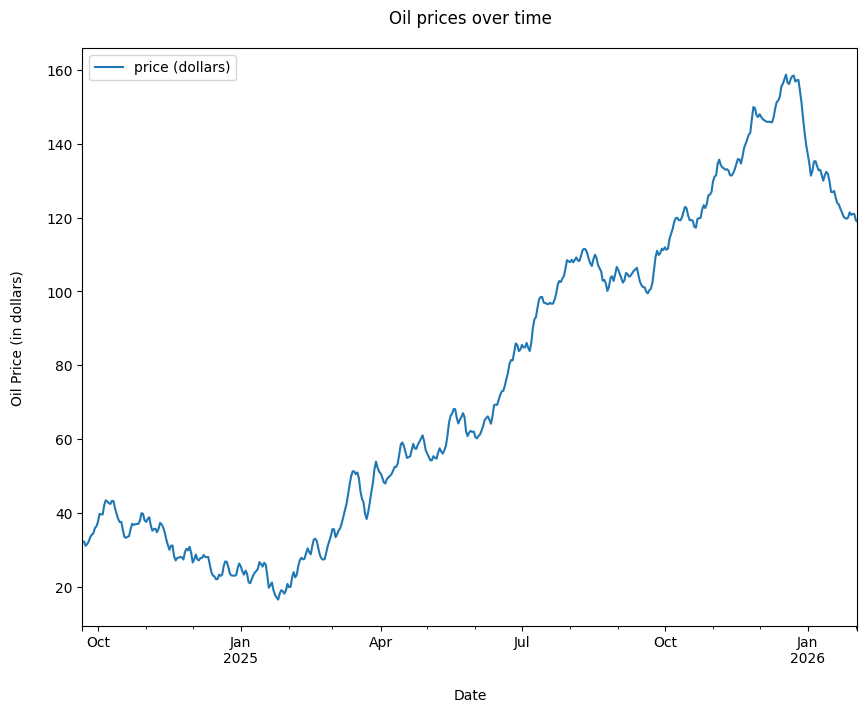

In [167]:
# Plot chart of oil prices overtime
oil.plot()
plt.title('Oil prices over time', pad=18)
plt.legend(loc='best')
plt.ylabel('Oil Price (in dollars)', labelpad=16)
plt.xlabel('Date', labelpad=16)
plt.show()

In [168]:
# Get month and year of each data point
oil_dup['month'] = oil_dup['date'].dt.month.astype('str')
oil_dup['year'] = oil_dup['date'].dt.year

In [169]:
month_dict = {
    '1':'January',
    '2':'February',
    '3':'March',
    '4':'April',
    '5':'May',
    '6':'June',
    '7':'July',
    '8':'August',
    '9':'September',
    '10':'October',
    '11':'November',
    '12':'December',
}

oil_dup['month'] = oil_dup['month'] = oil_dup['month'].replace(month_dict)

In [170]:
# Get the average oil prices in each year
oil_year_mean = oil_dup.pivot_table(index='year', values='price (dollars)',aggfunc='mean').round(2)

# Get the average oil prices for each month in each years
oil_month_mean_yearly = oil_dup.pivot_table(index='month', columns='year', values='price (dollars)',aggfunc='mean', fill_value=0).round(2)

# Get average oil prices for each month
oil_month_mean = oil_dup.pivot_table(index='month', values='price (dollars)',aggfunc='mean', fill_value=0).round(2)

In [171]:
oil_year_mean
oil_month_mean_yearly
#oil_month_mean

year,2024,2025,2026
month,,,
April,0.00,54.82,0.00
August,0.00,106.92,0.00
December,25.35,151.38,0.00
February,0.00,27.92,119.08
January,0.00,21.92,127.61
July,0.00,95.94,0.00
June,0.00,71.76,0.00
March,0.00,43.90,0.00
May,0.00,60.83,0.00
